In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns   
import numpy as np
from sklearn.preprocessing import RobustScaler, OneHotEncoder , PolynomialFeatures , OrdinalEncoder ,MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split ,GridSearchCV
from sklearn.ensemble import RandomForestRegressor , VotingRegressor ,StackingClassifier, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score , classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LinearRegression ,LogisticRegression
from xgboost import XGBRegressor , XGBClassifier
from sklearn.svm import SVC
import skfuzzy as fuzz


In [2]:
df = pd.read_csv("ai_student_impact_dataset.csv")

In [3]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


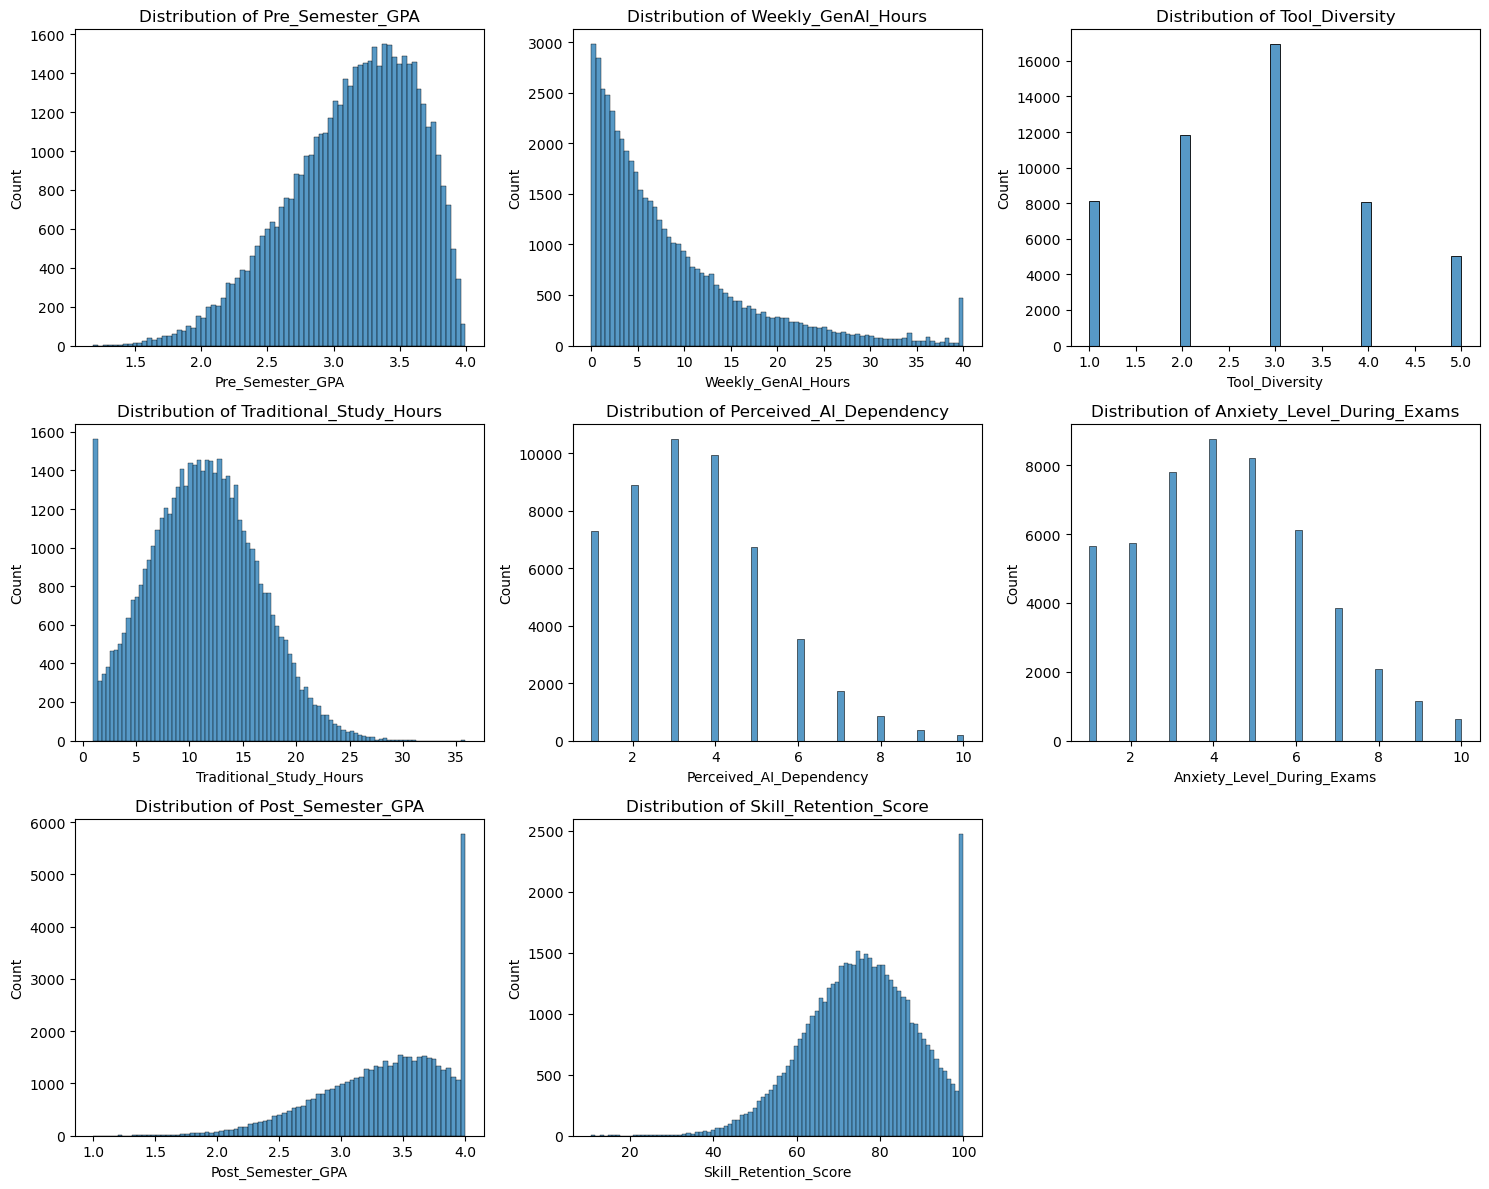

In [7]:
numeric_cols = [
    'Pre_Semester_GPA',
    'Weekly_GenAI_Hours',
    'Tool_Diversity',
    'Traditional_Study_Hours',
    'Perceived_AI_Dependency',
    'Anxiety_Level_During_Exams',
    'Post_Semester_GPA',
    'Skill_Retention_Score'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# hide unused plots
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1. Academic Performance (GPA Metrics)
   Pre_Semester_GPA: Displays a left-skewed normal distribution, indicating that the majority of students consistently maintain a high academic standing, clustered heavily between 3.0 and 3.5.

   Post_Semester_GPA: Also shows a left-skewed distribution but with a highly noticeable spike at exactly 4.0. This sudden increase in perfect scores warrants further investigation to determine if it correlates with AI tool usage.

2. Generative AI Engagement & Adoption
   Weekly_GenAI_Hours: Highly right-skewed (exponential decay pattern). Most students use GenAI moderately—typically under 10 hours per week. A minor cap/spike is observed at 40 hours, representing power users.

   Tool_Diversity: This is a discrete distribution peaking sharply at 3.0. This tells us that the standard student prefers multitasking with approximately three different AI platforms rather than relying on just one or trying too many.

   Perceived_AI_Dependency: The data is centrally distributed but leans lower (1 to 5). Most students feel in control and do not perceive themselves as overly dependent on AI, with very few rating their dependency at a critical level (8 to 10).

3. Study Habits & Psychological Factors
   Traditional_Study_Hours: Follows a classic bell-shaped normal distribution centered around 10–15 hours/week. However, a prominent isolated spike at 1 hour indicates a small segment of students who have almost entirely abandoned traditional studying.

   Anxiety_Level_During_Exams: Displays a balanced, slightly right-skewed distribution, showing moderate-to-high exam anxiety levels (mostly concentrated between scales 3 and 6).

   Skill_Retention_Score: Mostly normal, peaking healthily between 70–80. Interestingly, there is a sharp boundary spike at 100, suggesting a group of students who report perfect memory retention.

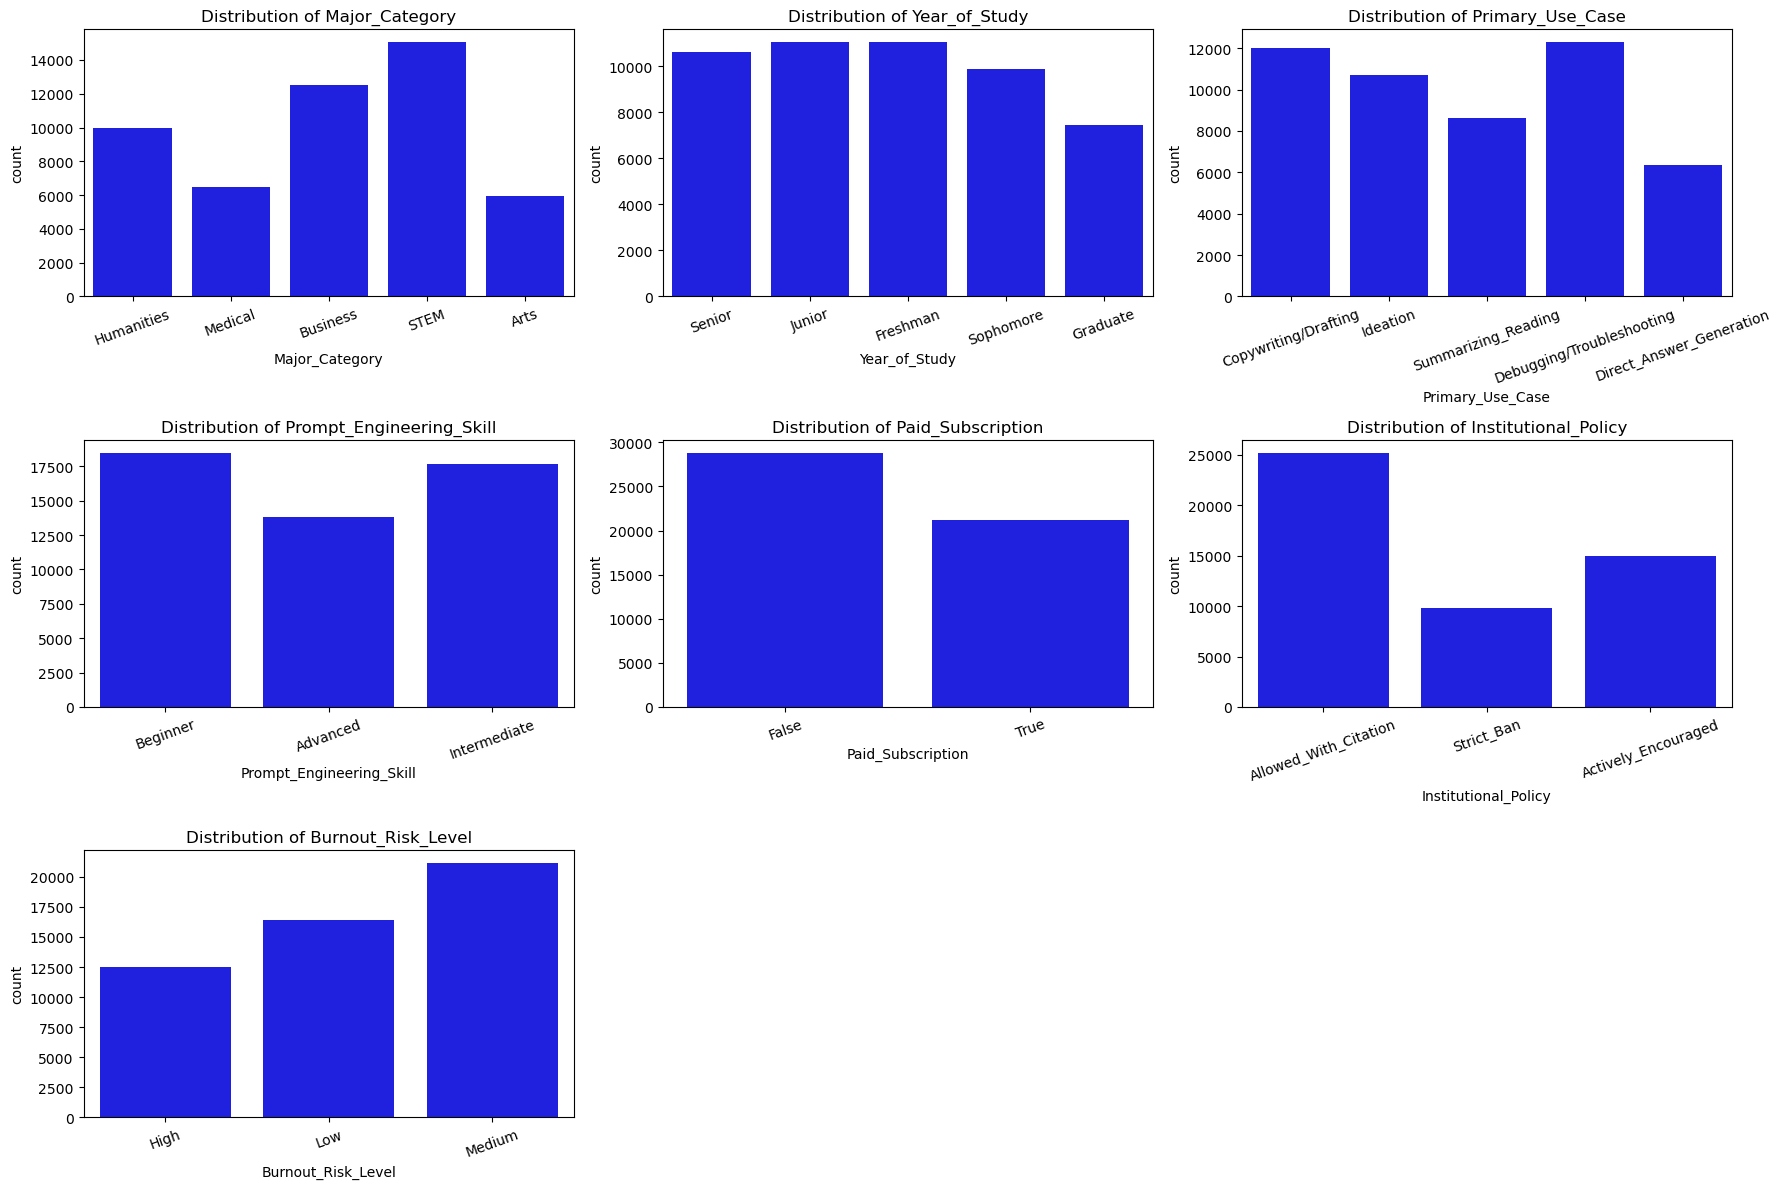

In [8]:
cat_cols = [
    'Major_Category',
    'Year_of_Study',
    'Primary_Use_Case',
    'Prompt_Engineering_Skill',
    'Paid_Subscription',
    'Institutional_Policy',
    'Burnout_Risk_Level'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df,
        x=col,
        ax=axes[i],
        color='blue'
    )

    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=20)

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1. Demographic & Academic Background
   Major_Category: Students from STEM fields represent the largest segment in the dataset, closely followed by Business and Humanities. Medical and Arts students are the least represented. This distribution is critical since AI tool adoption patterns heavily depend on the field of study.

   Year_of_Study: The dataset shows a relatively balanced representation across undergraduate years (Freshman, Junior, and Senior are almost equal, with a slight dip in Sophomores). Graduate students form the smallest group, which aligns with typical university population distributions.

2. AI Usage Patterns & Skills
   Primary_Use_Case: The most dominant reasons students use GenAI are Summarizing/Reading and Copywriting/Drafting. Ideation also shows a strong presence, while technical tasks like Debugging/Troubleshooting and Direct_Answer_Generation are less frequent but still significant.

   Prompt_Engineering_Skill: Interestingly, Beginner and Intermediate users dominate the sample, while Advanced users are the minority. This indicates that while AI adoption is high, deep optimization of prompts is still a developing skill among students.

   Paid_Subscription: The majority of students (False) rely on free tiers of AI tools. However, a massive portion (True, over 20,000 students) actually pays for premium subscriptions, highlighting how essential these tools have become to their workflow.

3. Institutional Policy & Student Well-being
   Institutional_Policy: University regulations heavily favor Allowed_With_Citation, followed by environments where AI is Actively_Encouraged. Strict bans (Strict_Ban) are the least common policy, indicating a general academic shift toward integrating AI rather than fighting it.

   Burnout_Risk_Level: This is a crucial psychological metric. The majority of students exhibit a Medium risk of burnout, followed by Low. However, a significant block of students is flagged with a High burnout risk, which provides a great opportunity to test if heavy AI reliance correlates with academic exhaustion.

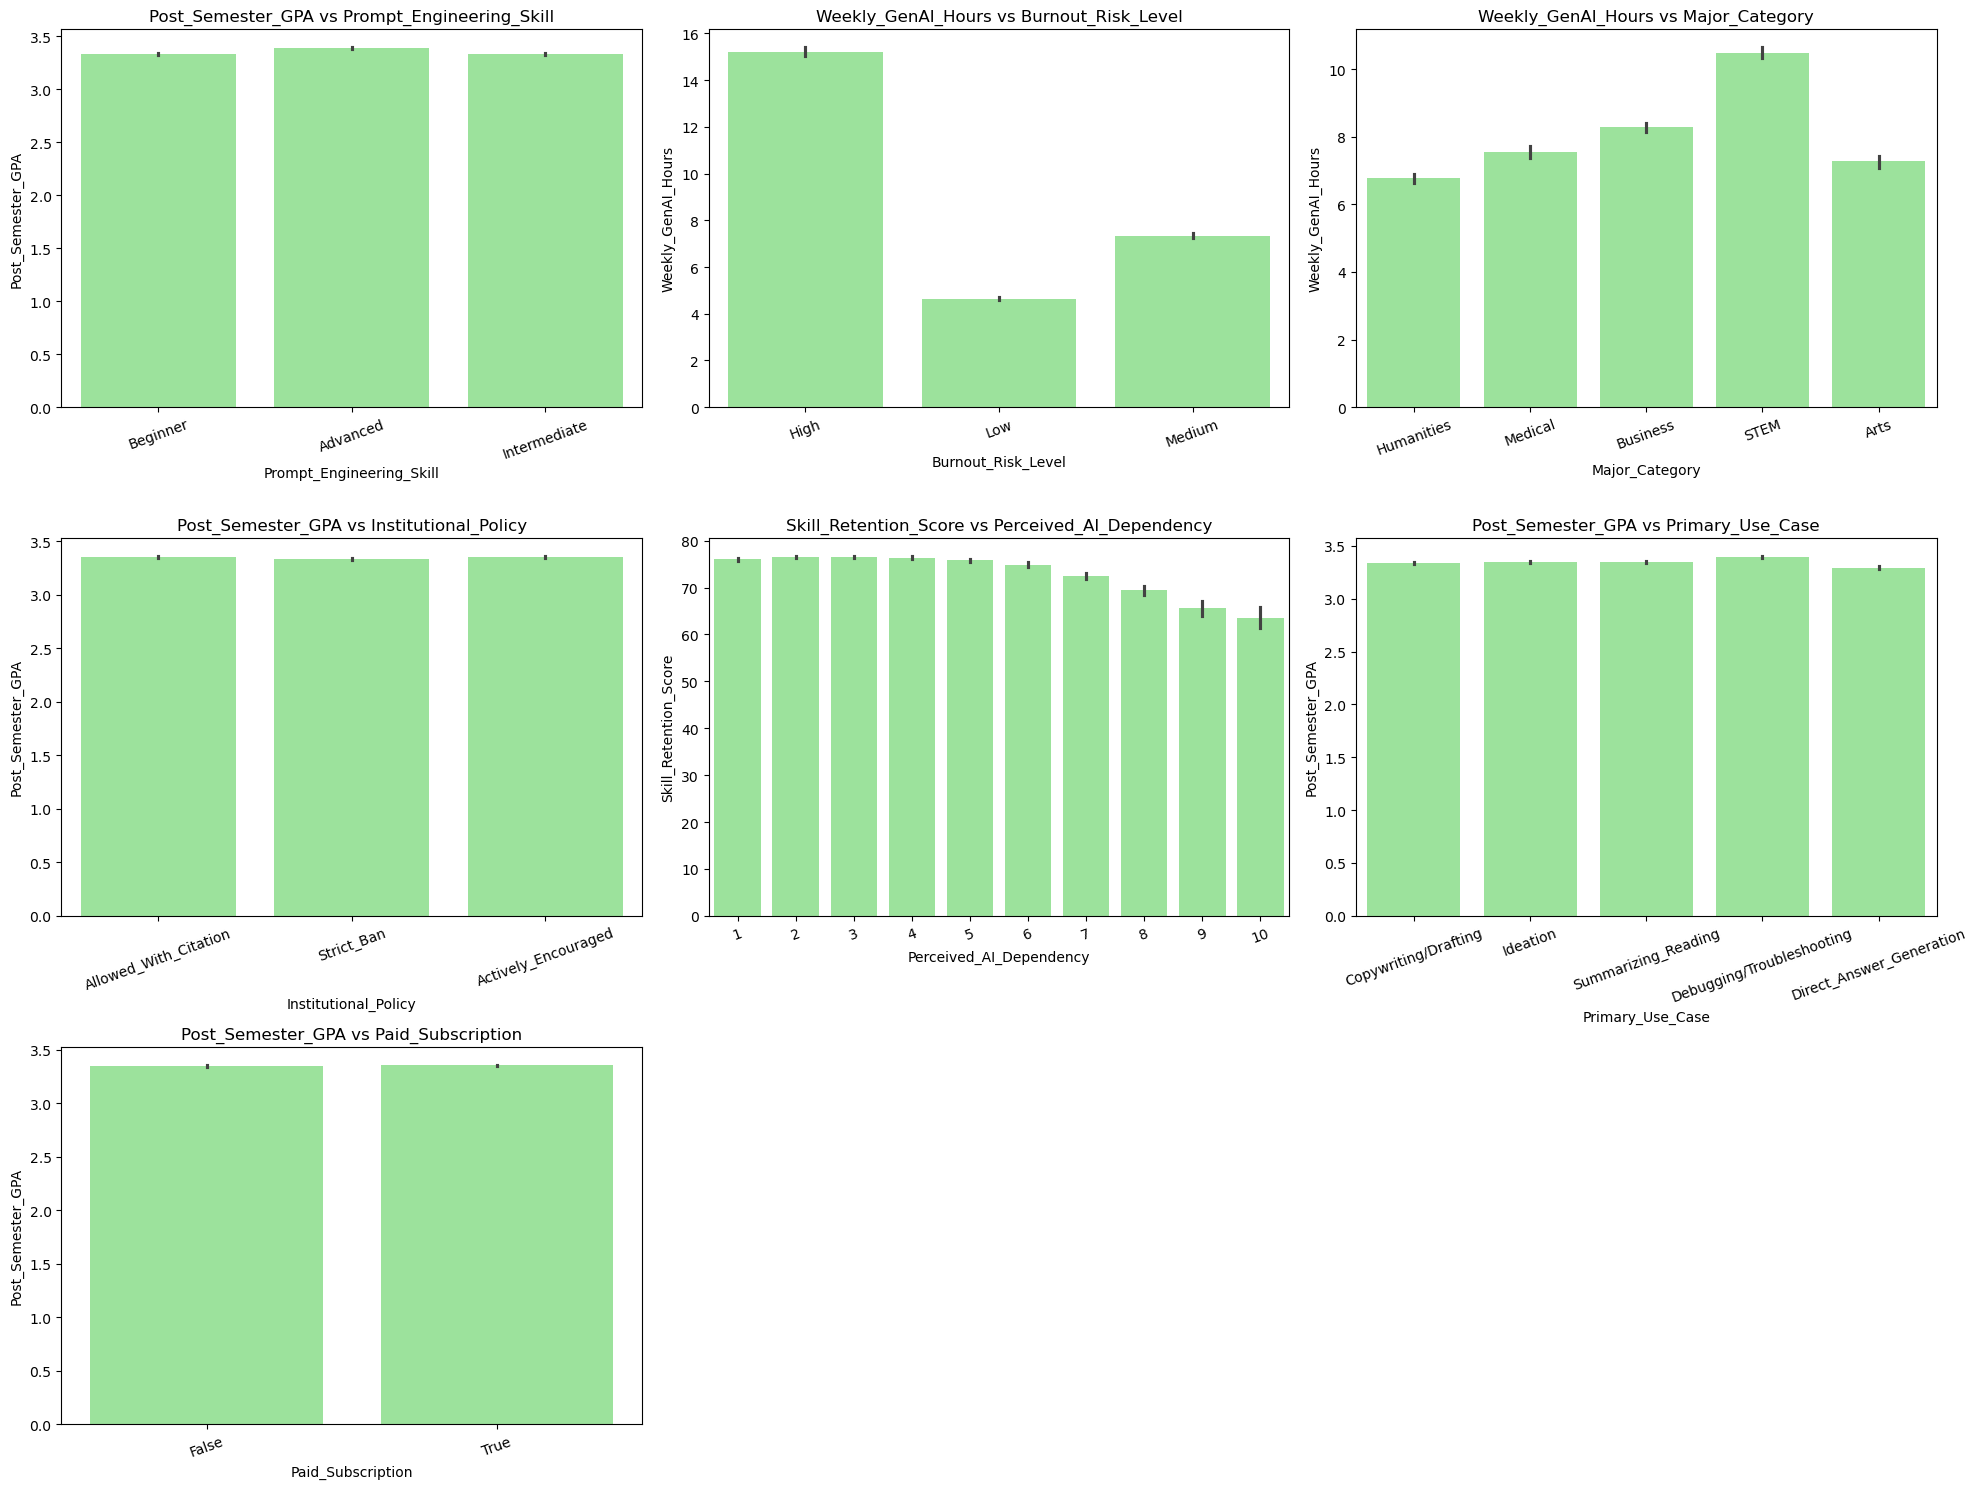

In [9]:
plots = [
    ('Prompt_Engineering_Skill', 'Post_Semester_GPA'),
    ('Burnout_Risk_Level', 'Weekly_GenAI_Hours'),
    ('Major_Category', 'Weekly_GenAI_Hours'),
    ('Institutional_Policy', 'Post_Semester_GPA'),
    ('Perceived_AI_Dependency', 'Skill_Retention_Score'),
    ('Primary_Use_Case', 'Post_Semester_GPA'),
    ('Paid_Subscription', 'Post_Semester_GPA')
]

fig, axes = plt.subplots(3, 3, figsize=(20, 15))

axes = axes.flatten()

for i, (x_col, y_col) in enumerate(plots):

    sns.barplot(
        data=df,
        x=x_col,
        y=y_col,
        ax=axes[i],
        color = "lightgreen"
    )

    axes[i].set_title(f'{y_col} vs {x_col}')

    axes[i].tick_params(axis='x', rotation=20)

for j in range(len(plots), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1. AI Engagement vs. Well-being & Academics
    Weekly_GenAI_Hours vs. Burnout_Risk_Level: There is a striking positive correlation here. Students with a High burnout risk level consume the highest number of AI hours per week (nearly 15 hours), whereas those with a Low risk level use it the least (around 5 hours). This suggests that heavy AI usage might be a symptom or a coping mechanism for academic stress and potential burnout.

    Weekly_GenAI_Hours vs. Major_Category: STEM students are heavily leading in terms of time spent using GenAI tools, averaging over 10 hours weekly. Business and Medical students follow, while Humanities and Arts show the lowest weekly hours. This aligns with the technical utility of current AI models.

2. The Cognitive Impact of AI Reliance
    Skill_Retention_Score vs. Perceived_AI_Dependency: This is one of the most critical findings in the dataset. There is a clear, steady negative trend. As a student's perceived dependency on AI increases from 1 to 10, their skill retention score drops noticeably (from around 76 down to 63). This strongly supports the hypothesis that cognitive over-reliance on AI may hinder long-term knowledge retention.

3. Factors with Minimal to No Impact on GPA
    Post_Semester_GPA vs. Prompt_Engineering_Skill: Interestingly, having advanced prompt engineering skills only yields a marginal, almost negligible increase in GPA compared to beginners.

    Post_Semester_GPA vs. Institutional_Policy: University policy seems to have no significant effect on student performance. Whether AI is strictly banned, allowed with citation, or actively encouraged, the average GPA remains practically identical across the board (around 3.3–3.4).

    Post_Semester_GPA vs. Paid_Subscription: Paying for a premium AI subscription does not translate to higher academic grades; the average GPA is statistically identical for both paid and free users.

    Post_Semester_GPA vs. Primary_Use_Case: The choice of use case (whether debugging, ideation, or summarizing) shows minimal variation in GPA, though students using it for Debugging/Troubleshooting exhibit a tiny, fractional advantage.

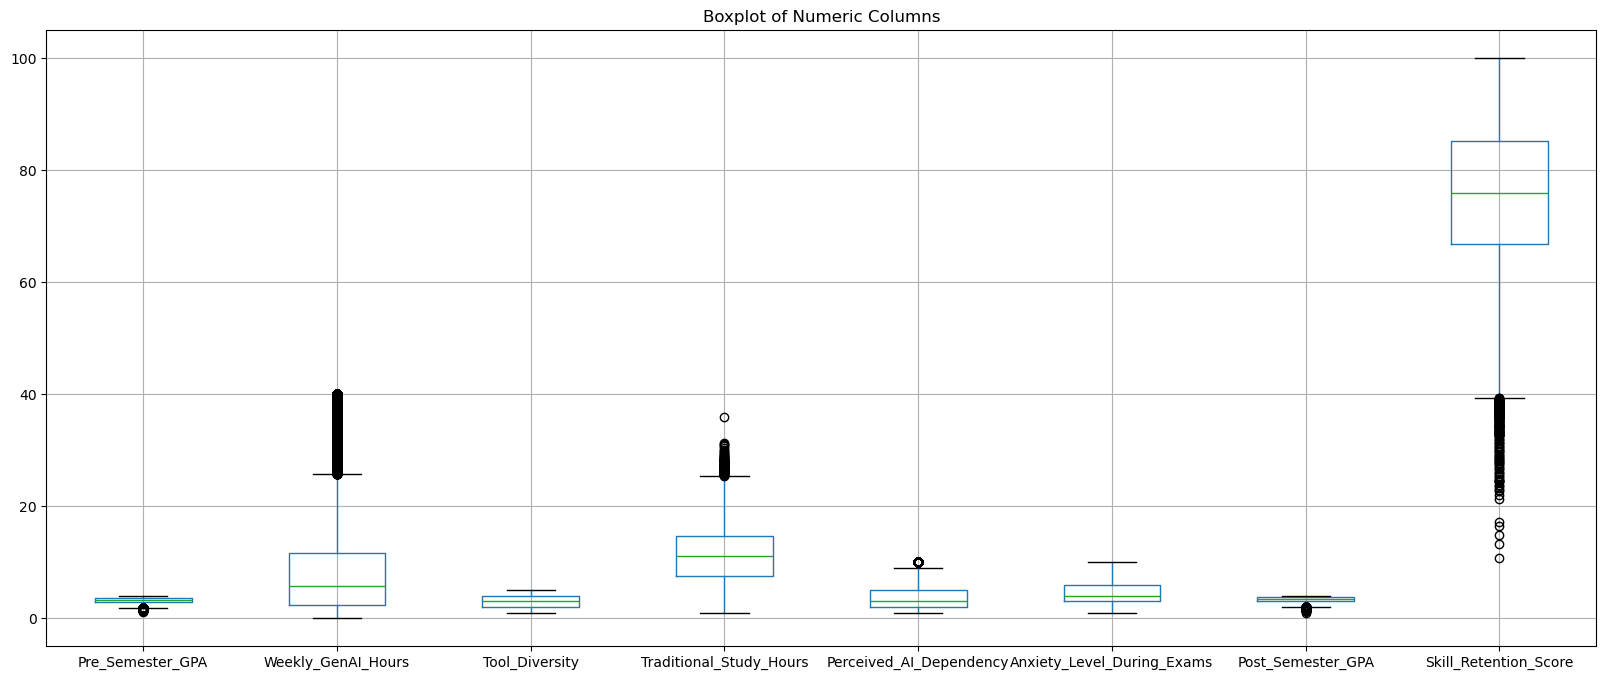

In [10]:
df[numeric_cols].boxplot(figsize=(20,8))
plt.title("Boxplot of Numeric Columns")
plt.show()

1. Strongest Positive Correlations (Key Drivers)
    Pre-Semester vs. Post-Semester GPA (0.93): Unsurprisingly, the strongest correlation in the entire dataset is between a student's prior GPA and their subsequent GPA. This proves that academic baseline consistency is the most resilient predictor of grades, regardless of external AI interventions.

    Weekly GenAI Hours vs. Perceived AI Dependency (0.67): There is a strong, statistically significant positive correlation between actual time spent using GenAI and a student's self-reported psychological dependency. More hours naturally breed a higher feeling of reliance.

2. Moderate to Weak Interactions (Subtle Trends)
    Anxiety and AI Factors: Anxiety_Level_During_Exams shows a mild positive correlation with both Perceived_AI_Dependency (0.31) and Weekly_GenAI_Hours (0.27). This implies that higher exam anxiety might push students to spend more hours on AI, or conversely, relying heavily on AI may slightly heighten exam anxiety.

    Tool Diversity vs. Skill Retention (0.20): A slight positive correlation exists here, suggesting that exploring a wider variety of AI tools might correlate with marginally better skill retention compared to overusing a single tool.

3. Confirmed Negative Correlations (The Trade-offs)
    Weekly GenAI Hours vs. Traditional Study Hours (−0.16): This directly quantifies the negative trend observed in the previous scatter plot, confirming a mild time-substitution effect where more AI hours nudge traditional studying downward.

    Weekly GenAI Hours vs. Skill Retention (−0.12): While weak, the negative coefficient solidifies our earlier observation that extensive AI hours may slightly compromise long-term memory retention.

4. Surprising Dead Ends (Zero Correlation)
    AI vs. Final Grades: Shockingly, Weekly_GenAI_Hours has a correlation of −0.02 with Post_Semester_GPA. Similarly, Perceived_AI_Dependency sits at −0.01. This provides a massive insight for the project's conclusion: AI consumption does not directly scale academic performance up or down. It serves as a process optimizer rather than a direct grade booster.

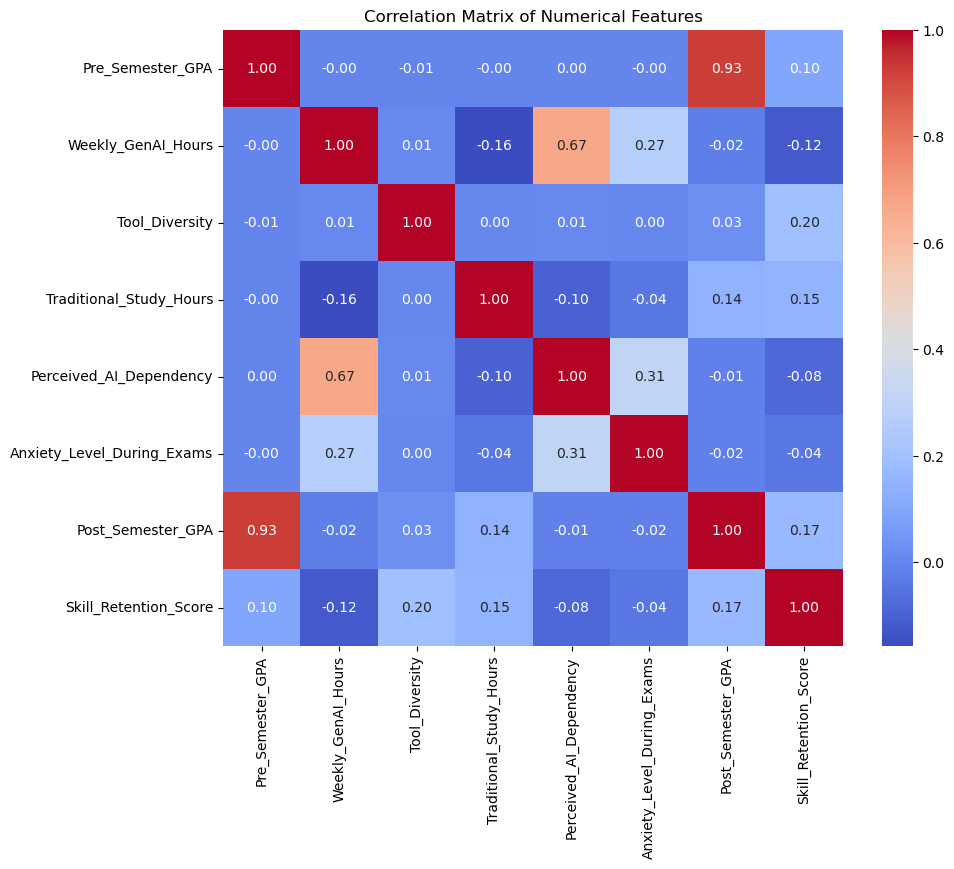

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [12]:
x = df.drop(columns=['Student_ID', 'Post_Semester_GPA', 'Burnout_Risk_Level'])
y_gpa = df['Post_Semester_GPA']

x_train_g, x_test_g, y_train_g, y_test_g = train_test_split(x, y_gpa, test_size=0.2, random_state=42)

num_features = [
    'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours', 
    'Tool_Diversity', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Skill_Retention_Score'
]
cat_features = [
    'Major_Category', 'Year_of_Study', 'Primary_Use_Case', 
    'Prompt_Engineering_Skill', 'Institutional_Policy'
]
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)



In [13]:
rf_base = RandomForestRegressor(random_state=42)

gpa_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_base) 
])

param_grid_gpa = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [6, 10, 15, 20, 30],        
    'model__min_samples_split': [10, 20, 50, 70, 100],   
    'model__min_samples_leaf': [4, 8, 16],
    'model__max_features': ['sqrt', 'log2']
}

grid_gpa = GridSearchCV(
    estimator=gpa_pipeline,      
    param_grid=param_grid_gpa,
    cv=5,                                           
    scoring='r2',
    n_jobs=-1
)

grid_gpa.fit(x_train_g, y_train_g)

print("   Best Parameters Found   ")
print(grid_gpa.best_params_)

best_rf_step = grid_gpa.best_estimator_.named_steps['model']


   Best Parameters Found   
{'model__max_depth': 30, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 200}


In [14]:
linear = LinearRegression()

poly = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2)),
    ('lr_model', LinearRegression())
])

best_rf = best_rf_step 

triple_voter = VotingRegressor(estimators=[
    ('linear', linear),
    ('poly', poly),
    ('rf', best_rf)
])

voting_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('ultimate_voter', triple_voter)
])

voting_pipeline.fit(x_train_g, y_train_g)

y_train_pred = voting_pipeline.predict(x_train_g)
y_test_pred = voting_pipeline.predict(x_test_g)

voting_train_r2 = r2_score(y_train_g, y_train_pred)
voting_test_r2 = r2_score(y_test_g, y_test_pred)

voting_train_rmse = np.sqrt(mean_squared_error(y_train_g, y_train_pred))
voting_test_rmse = np.sqrt(mean_squared_error(y_test_g, y_test_pred))

voting_train_mae = mean_absolute_error(y_train_g, y_train_pred)
voting_test_mae = mean_absolute_error(y_test_g, y_test_pred)

print("="*50)
print("VOTING ENSEMBLE METRICS")
print("="*50)
print(f"Train R2 Score : {voting_train_r2*100:.2f}%")
print(f"Test R2 Score  : {voting_test_r2*100:.2f}%")
print("-"*50)
print(f"Train RMSE     : {voting_train_rmse:,.2f}")
print(f"Test RMSE      : {voting_test_rmse:,.2f}")
print("-"*50)
print(f"Train MAE      : {voting_train_mae:,.2f}")
print(f"Test MAE       : {voting_test_mae:,.2f}")
print("="*50)


VOTING ENSEMBLE METRICS
Train R2 Score : 92.20%
Test R2 Score  : 90.76%
--------------------------------------------------
Train RMSE     : 0.14
Test RMSE      : 0.15
--------------------------------------------------
Train MAE      : 0.11
Test MAE       : 0.12


In [29]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

xgb_pipeline.fit(x_train_g, y_train_g)

y_train_pred = xgb_pipeline.predict(x_train_g)
y_test_pred = xgb_pipeline.predict(x_test_g)

xgb_train_r2 = r2_score(y_train_g, y_train_pred)
xgb_test_r2 = r2_score(y_test_g, y_test_pred)

xgb_train_rmse = np.sqrt(mean_squared_error(y_train_g, y_train_pred))
xgb_test_rmse = np.sqrt(mean_squared_error(y_test_g, y_test_pred))

xgb_train_mae = mean_absolute_error(y_train_g, y_train_pred)
xgb_test_mae = mean_absolute_error(y_test_g, y_test_pred)

print("="*50)
print("XGBOOST REGRESSION METRICS")
print("="*50)
print(f"Train R2 Score : {xgb_train_r2*100:.2f}%")
print(f"Test R2 Score  : {xgb_test_r2*100:.2f}%")
print("-"*50)
print(f"Train RMSE     : {xgb_train_rmse:,.2f}")
print(f"Test RMSE      : {xgb_test_rmse:,.2f}")
print("-"*50)
print(f"Train MAE      : {xgb_train_mae:,.2f}")
print(f"Test MAE       : {xgb_test_mae:,.2f}")
print("="*50)

XGBOOST REGRESSION METRICS
Train R2 Score : 92.16%
Test R2 Score  : 91.53%
--------------------------------------------------
Train RMSE     : 0.14
Test RMSE      : 0.14
--------------------------------------------------
Train MAE      : 0.11
Test MAE       : 0.11


Train Accuracy: 69.55%
Test Accuracy:  53.09%

--- Classification Report ---
              precision    recall  f1-score   support

         Low       0.52      0.48      0.50      3269
      Medium       0.48      0.61      0.54      4195
        High       0.69      0.46      0.55      2536

    accuracy                           0.53     10000
   macro avg       0.56      0.52      0.53     10000
weighted avg       0.55      0.53      0.53     10000



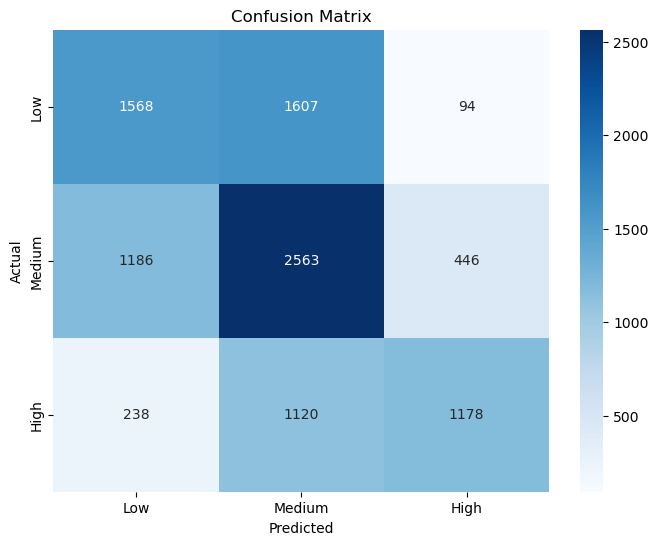

In [18]:
y_class = df['Burnout_Risk_Level']
x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(x, y_class, test_size=0.2, random_state=42)

categories = [['Low', 'Medium', 'High']]

ordinal_enc = OrdinalEncoder(categories=categories)

y_train_encoded = ordinal_enc.fit_transform(y_train_c.values.reshape(-1, 1))
y_test_encoded = ordinal_enc.transform(y_test_c.values.reshape(-1, 1))

y_train_c_encoded = y_train_encoded.ravel()
y_test_c_encoded = y_test_encoded.ravel()

xgb_classifier = XGBClassifier(
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss'
)

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', xgb_classifier)
])

xgb_pipeline.fit(x_train_c, y_train_c_encoded)


# Train predictions
y_train_pred = xgb_pipeline.predict(x_train_c)
train_acc = accuracy_score(y_train_c_encoded, y_train_pred)

# Test predictions
y_test_pred = xgb_pipeline.predict(x_test_c)
test_acc = accuracy_score(y_test_c_encoded, y_test_pred)

print(f"Train Accuracy: {train_acc * 100:.2f}%")
print(f"Test Accuracy:  {test_acc * 100:.2f}%")


labels = ['Low', 'Medium', 'High']

print("\n--- Classification Report ---")
print(classification_report(
    y_test_c_encoded,
    y_test_pred,
    target_names=labels
))

plt.figure(figsize=(8, 6))

cm = confusion_matrix(y_test_c_encoded, y_test_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Fitting 5 folds for each of 16 candidates, totalling 80 fits
{'classifier__C': 10, 'classifier__gamma': 0.001, 'classifier__kernel': 'rbf'}
Train Accuracy: 64.74%
Test Accuracy: 53.82%

--- Classification Report ---
              precision    recall  f1-score   support

         Low       0.53      0.50      0.52      3269
      Medium       0.49      0.60      0.54      4195
        High       0.69      0.48      0.56      2536

    accuracy                           0.54     10000
   macro avg       0.57      0.53      0.54     10000
weighted avg       0.55      0.54      0.54     10000



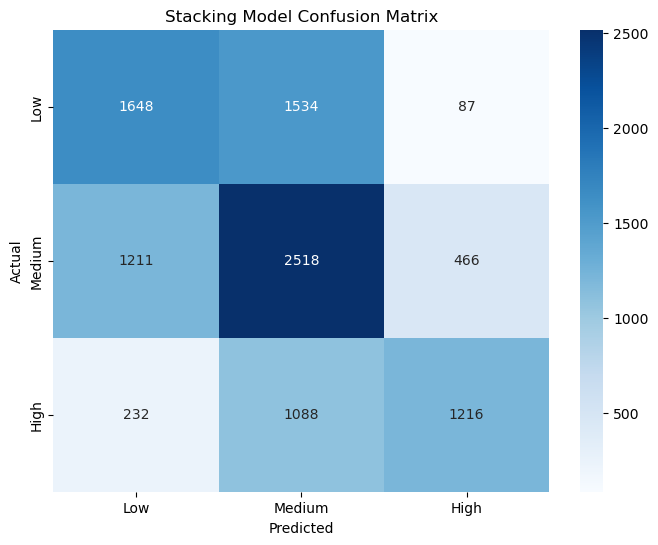

In [19]:
svc_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC())
])
param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': [1, 0.1, 0.01, 0.001],
    'classifier__kernel': ['rbf']
}
grid = GridSearchCV(
    svc_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(x_train_c, y_train_c_encoded)
best_svc = grid.best_estimator_

print(grid.best_params_)

log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

stacking_model = StackingClassifier(
    estimators=[
        ('svm', best_svc),
        ('lr', log_model),
        ('rf', rf_model)
    ],
    
    final_estimator=LogisticRegression(),
    
    cv=5
)

stacking_model.fit(x_train_c, y_train_c_encoded)


y_train_pred = stacking_model.predict(x_train_c)
train_acc = accuracy_score(y_train_c_encoded, y_train_pred)

y_test_pred = stacking_model.predict(x_test_c)
test_acc = accuracy_score(y_test_c_encoded, y_test_pred)

print(f"Train Accuracy: {train_acc * 100:.2f}%")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

print("\n--- Classification Report ---")
print(classification_report(
    y_test_c_encoded,
    y_test_pred,
    target_names=labels
))

cm = confusion_matrix(y_test_c_encoded, y_test_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Stacking Model Confusion Matrix')
plt.show()


In [20]:
fuzz_features = [
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours',
    'Perceived_AI_Dependency',
    'Anxiety_Level_During_Exams'
]
x = df[fuzz_features].values
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
x_fuzzy = x_scaled.T
n_clusters = 3

cntr, membership, initial_membership, distance, j, num_itr, fpc = fuzz.cluster.cmeans(
    x_fuzzy,
    c=n_clusters,
    m=1.3,
    error=0.005,
    maxiter=1000,
    init=None
)
df['Behavior_Cluster'] = np.argmax(membership, axis=0)
df['Cluster_0_Mem'] = membership[0]
df['Cluster_1_Mem'] = membership[1]
df['Cluster_2_Mem'] = membership[2]

print(f"Fuzzy Partition Coefficient: {fpc*100:.2f}%")
for i in range(n_clusters):
    print(f"\nCluster {i}")
    print(df[df['Behavior_Cluster'] == i][fuzz_features].mean())

Fuzzy Partition Coefficient: 84.15%

Cluster 0
Weekly_GenAI_Hours            23.132552
Traditional_Study_Hours        9.437829
Perceived_AI_Dependency        6.208508
Anxiety_Level_During_Exams     5.699753
dtype: float64

Cluster 1
Weekly_GenAI_Hours             5.180411
Traditional_Study_Hours       11.550425
Perceived_AI_Dependency        2.631289
Anxiety_Level_During_Exams     2.475286
dtype: float64

Cluster 2
Weekly_GenAI_Hours             6.047256
Traditional_Study_Hours       11.554325
Perceived_AI_Dependency        3.390502
Anxiety_Level_During_Exams     5.762970
dtype: float64


In [21]:
cluster_summary = df.groupby('Behavior_Cluster').agg(
    count=('Behavior_Cluster', 'size'),
    Weekly_GenAI_Hours=('Weekly_GenAI_Hours', 'mean'),
    Traditional_Study_Hours=('Traditional_Study_Hours', 'mean'),
    Perceived_AI_Dependency=('Perceived_AI_Dependency', 'mean'),
    Anxiety_Level_During_Exams=('Anxiety_Level_During_Exams', 'mean')
)
cluster_summary

,count,Weekly_GenAI_Hours,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams
Behavior_Cluster,,,,,
0,8110,23.132552,9.437829,6.208508,5.699753
1,22538,5.180411,11.550425,2.631289,2.475286
2,19352,6.047256,11.554325,3.390502,5.762970


Cluster 0 – High AI Dependency Learners:
Students with heavy reliance on generative AI tools, lower traditional study time, and higher anxiety levels. This group shows potential academic stress linked to AI overuse.

Cluster 1 – Traditional Learners:
Students with low AI dependency, higher traditional study hours, and highest anxiety levels. They represent students who rely primarily on traditional study methods and experience higher academic stress.

Cluster 2 – Stable Low-Stress Traditional Learners:
This cluster represents students with low AI dependency, consistent traditional study habits, and the lowest anxiety levels. They show a stable and balanced learning pattern with minimal stress.

**Key Insight**

It was observed that students with extreme study behaviors tend to experience higher stress levels. High AI-dependent learners show increased academic pressure, while traditional learners also exhibit relatively elevated anxiety despite lower AI usage. In contrast, students with mixed or balanced behavior demonstrate lower and more stable stress levels, suggesting that moderation between AI usage and traditional study may contribute to better academic well-being. Additionally, stable learners show the most consistent performance with minimal anxiety, highlighting the importance of balanced study habits.

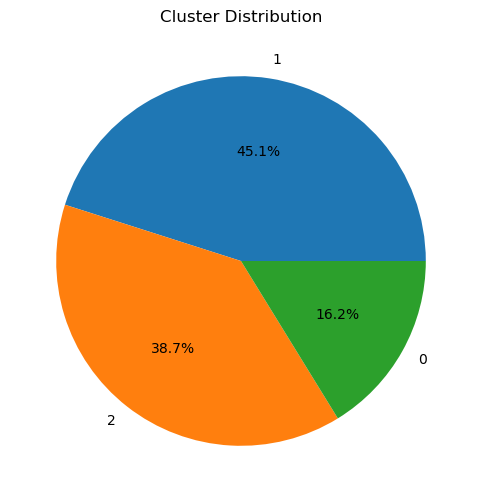

In [22]:
df['Behavior_Cluster'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Cluster Distribution')
plt.ylabel('')
plt.show()

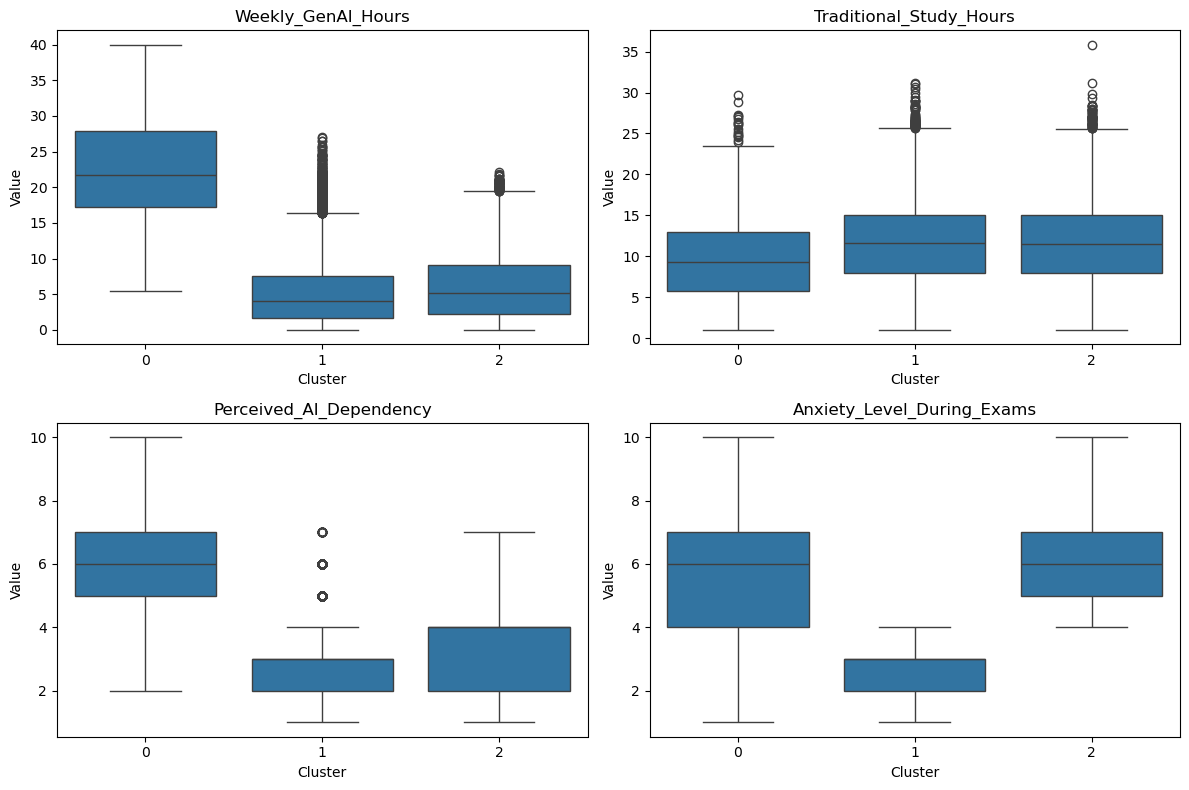

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(fuzz_features):
    sns.boxplot(
        x='Behavior_Cluster',
        y=col,
        data=df,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

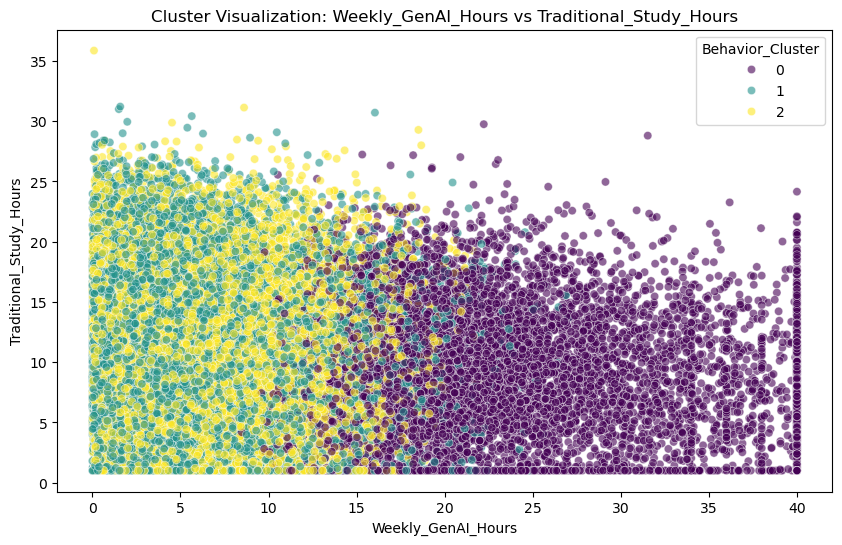

In [24]:
feature_x = 'Weekly_GenAI_Hours'
feature_y = 'Traditional_Study_Hours'

# الرسم
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x=feature_x, 
    y=feature_y, 
    hue='Behavior_Cluster',
    palette='viridis', 
    alpha=0.6
)

plt.title(f'Cluster Visualization: {feature_x} vs {feature_y}')
plt.show()

there is overlap thats why classification accuracy was low

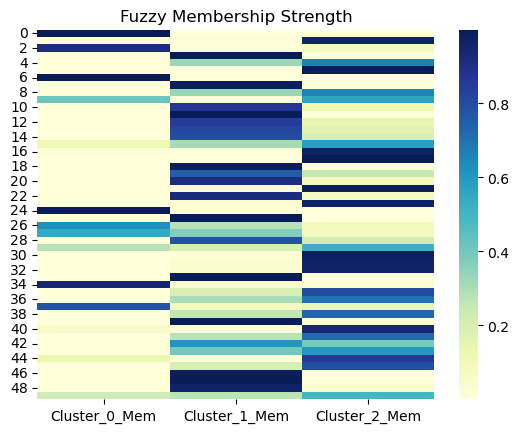

In [ ]:
sns.heatmap(df[['Cluster_0_Mem','Cluster_1_Mem','Cluster_2_Mem']].head(50),
            cmap='YlGnBu')

plt.title('Fuzzy Membership Strength')
plt.show()

In [30]:
import joblib

joblib.dump(xgb_pipeline, "gpa_model.pkl")
joblib.dump(stacking_model, "burnout_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(cntr, "fuzzy_centers.pkl")

['fuzzy_centers.pkl']

In [34]:
def skill_retention_score(genai_hours, study_hours, prompt_skill, anxiety):
    
    skill_map = {'Beginner': 1, 'Intermediate': 2, 'Advanced': 3}
    skill_num = skill_map[prompt_skill]
    
    genai_ratio = genai_hours / (genai_hours + study_hours)
    
    score = (57.58
             + 32.05 * genai_ratio
             + 8.23  * skill_num
             - 2.02  * anxiety)
    
    return round(min(max(score, 0), 100), 2)

In [ ]:
def recommend(cluster, burnout):

    match (cluster, burnout):

        # Cluster 0 – High AI Dependency Learners
        case (0, "Low"):
            return (
                "You're using AI effectively without feeling overwhelmed — that's a good sign. "
                "To stay on track, start practicing problems independently before turning to AI, "
                "so you build confidence in your own thinking."
            )

        case (0, "Medium"):
            return (
                "Your heavy AI usage may be adding hidden pressure. "
                "Try setting boundaries: use AI to check your work, not replace it. "
                "Dedicate at least 30 minutes daily to solving problems on your own first."
            )

        case (0, "High"):
            return (
                "High AI dependency combined with high stress is a warning sign. "
                "Step back from over-relying on AI for answers — it may be weakening your ability to think under exam pressure. "
                "Focus on rebuilding independent study habits and seek academic support if needed."
            )

        # Cluster 1 – Traditional Learners
        case (1, "Low"):
            return (
                "Your traditional study habits are paying off. "
                "Consider selectively integrating AI tools — not to replace your methods, "
                "but to save time on research and summarizing, so you can focus energy on deeper understanding."
            )

        case (1, "Medium"):
            return (
                "You're putting in strong effort the traditional way, but stress is building. "
                "This might mean you're overloading yourself. "
                "Try using AI tools to speed up routine tasks like note summarizing, "
                "and protect more time for rest and review."
            )

        case (1, "High"):
            return (
                "You're studying hard but burning out. Traditional methods alone can be exhausting "
                "when the workload is heavy. Consider using AI as a study assistant to reduce effort "
                "on low-value tasks, and prioritize sleep and scheduled breaks — consistency matters more than hours."
            )

        # Cluster 2 – Stable Low-Stress Traditional Learners
        case (2, "Low"):
            return (
                "You have one of the healthiest study patterns — balanced, consistent, and low stress. "
                "Keep this rhythm and consider exploring AI tools gradually "
                "to enhance your efficiency without disrupting what's already working."
            )

        case (2, "Medium"):
            return (
                "Your stable habits are solid, but something is starting to add pressure. "
                "Review your recent schedule for overcommitments and make sure "
                "you're maintaining the balance that made your pattern successful."
            )

        case (2, "High"):
            return (
                "Stress is rising despite your stable routine — this could be external pressure "
                "like exams or deadlines piling up. Don't break your good habits under pressure. "
                "Focus on stress management techniques alongside your study routine."
            )

        case _:
            return "No recommendation available for this combination."